<a href="https://colab.research.google.com/github/sujith-kumara/Design-a-Deep-Learning-Framework-GNR-638-Assignment/blob/main/Assignment_2/final_DenseNet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp '/content/drive/MyDrive/assignment_GNR638/Copy of train_data.zip' '/content'


In [ ]:
!unzip -q 'Copy of train_data.zip'


In [ ]:
!pip install timm torchmetrics scikit-learn albumentations fvcore seaborn ptflops





     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.2 MB/s eta 0:00:00
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=5089ebeb54374182c0c40a016cc50b94f798d7cf6dc83d3ad11b4379d31e9d18
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=be6f978024a2b5acc4edf3dd5c7b6086c987dcb21d0d13f20305a6c564f51a86
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import os
import random
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from fvcore.nn import FlopCountAnalysis, parameter_count_table
from torch.utils.data import Subset
import cv2
from ptflops import get_model_complexity_info



In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)
NUM_CLASSES = 30
Nepochs = 30 #Backbone epoch
Fepochs = 10 #Fine-tuning epoch
Oepochs = 20 #Oneshot epoch

In [ ]:
model_name = "densenet121"

In [ ]:
train_dir = "/content/AID_split/train"
val_dir = "/content/AID_split/val"
test_dir = "/content/AID_split/test"
base = "/content/AID_split"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Preparation



##Splitting Dataset

In [ ]:
source_dir = "/content/train_data"
output_dir = base

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for split in ['train','val','test']:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)
classes = os.listdir(source_dir)

for cls in classes:

    class_path = os.path.join(source_dir, cls)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    random.shuffle(images)

    total = len(images)

    train_end = int(train_ratio * total)
    val_end = int((train_ratio + val_ratio) * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]


    for split_name, split_images in zip(
        ['train','val','test'],
        [train_images, val_images, test_images]
    ):

        split_class_dir = os.path.join(output_dir, split_name, cls)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in split_images:

            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)

            shutil.copy(src, dst)

print("Dataset successfully split!")


Dataset successfully split!


## Counting data

In [ ]:
def count_images(folder):

    total = 0

    for root, dirs, files in os.walk(folder):
        total += len(files)

    return total


train_count = count_images(os.path.join(output_dir,"train"))
val_count = count_images(os.path.join(output_dir,"val"))
test_count = count_images(os.path.join(output_dir,"test"))

print("Train images:", train_count)
print("Validation images:", val_count)
print("Test images:", test_count)


Train images: 4882
Validation images: 1047
Test images: 1064


## Tranformation

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


## Loading data

In [ ]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_transform
)

print("Number of classes:", len(train_dataset.classes))


Number of classes: 30


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


# Experiment 1

In [ ]:
 def initialize_model(model_name):
    model = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES)
    model = model.to(device)
    return model

In [ ]:
def report_efficiency(model):
    """Reports parameters, MACs, and FLOPs."""
    macs, params = get_model_complexity_info(model, (3, 224, 224), as_strings=True, print_per_layer_stat=False)
    print(f"Parameters: {params}, MACs: {macs}")

In [ ]:
def freeze_all_but_last(model):
  for param in model.parameters():
    param.requires_grad = False

  for param in model.classifier.parameters():
      param.requires_grad = True

  return model

In [ ]:
criterion = nn.CrossEntropyLoss()


In [ ]:
def train_epoch_exp1(model, loader):


    print("Training ...")
    model.train()

    total = 0
    correct = 0
    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    acc = correct / total

    return running_loss / len(loader), acc


In [ ]:
def evaluate(model, loader):

    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs,1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total


In [ ]:
model = initialize_model(model_name)

optimizer = optim.Adam(
    model.classifier.parameters(), # different for each model
    lr=0.001
)

report_efficiency(model)
model = freeze_all_but_last(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Parameters: 6.98 M, MACs: 2.87 GMac


In [ ]:
print(f"\n{'='*50}\nStarting Experiment 1: Linear Probe for {model_name}\n{'='*50}")


train_acc_list = []
val_acc_list = []

for epoch in range(Nepochs):

    loss, train_acc = train_epoch_exp1(model, train_loader)

    val_acc = evaluate(model, val_loader)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(
        f"Epoch {epoch+1}/{Nepochs} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )



Starting Experiment 1: Linear Probe for densenet121
Training ...
Epoch 1/30 | Train Acc: 0.5901 | Val Acc: 0.7765
Training ...
Epoch 2/30 | Train Acc: 0.8212 | Val Acc: 0.8472
Training ...
Epoch 3/30 | Train Acc: 0.8560 | Val Acc: 0.8529
Training ...
Epoch 4/30 | Train Acc: 0.8794 | Val Acc: 0.8720
Training ...
Epoch 5/30 | Train Acc: 0.9000 | Val Acc: 0.8768
Training ...
Epoch 6/30 | Train Acc: 0.9019 | Val Acc: 0.8968
Training ...
Epoch 7/30 | Train Acc: 0.9148 | Val Acc: 0.8883
Training ...
Epoch 8/30 | Train Acc: 0.9222 | Val Acc: 0.8949
Training ...
Epoch 9/30 | Train Acc: 0.9283 | Val Acc: 0.8863
Training ...
Epoch 10/30 | Train Acc: 0.9295 | Val Acc: 0.9064
Training ...
Epoch 11/30 | Train Acc: 0.9396 | Val Acc: 0.9007
Training ...
Epoch 12/30 | Train Acc: 0.9433 | Val Acc: 0.9007
Training ...
Epoch 13/30 | Train Acc: 0.9474 | Val Acc: 0.9064
Training ...
Epoch 14/30 | Train Acc: 0.9467 | Val Acc: 0.9026
Training ...
Epoch 15/30 | Train Acc: 0.9472 | Val Acc: 0.9112
Training ..

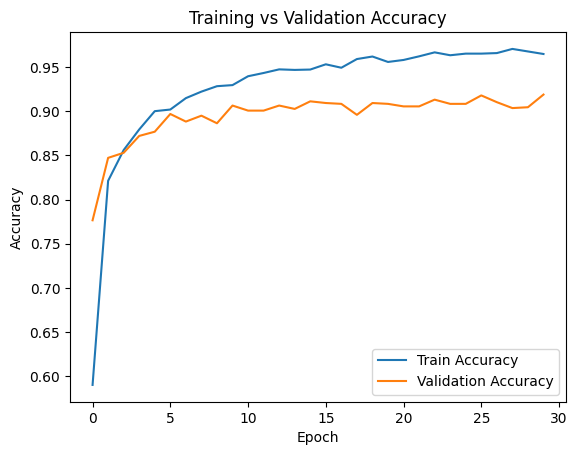

In [ ]:
plt.plot(train_acc_list,label="Train Accuracy")
plt.plot(val_acc_list,label="Validation Accuracy")

plt.legend()
plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()


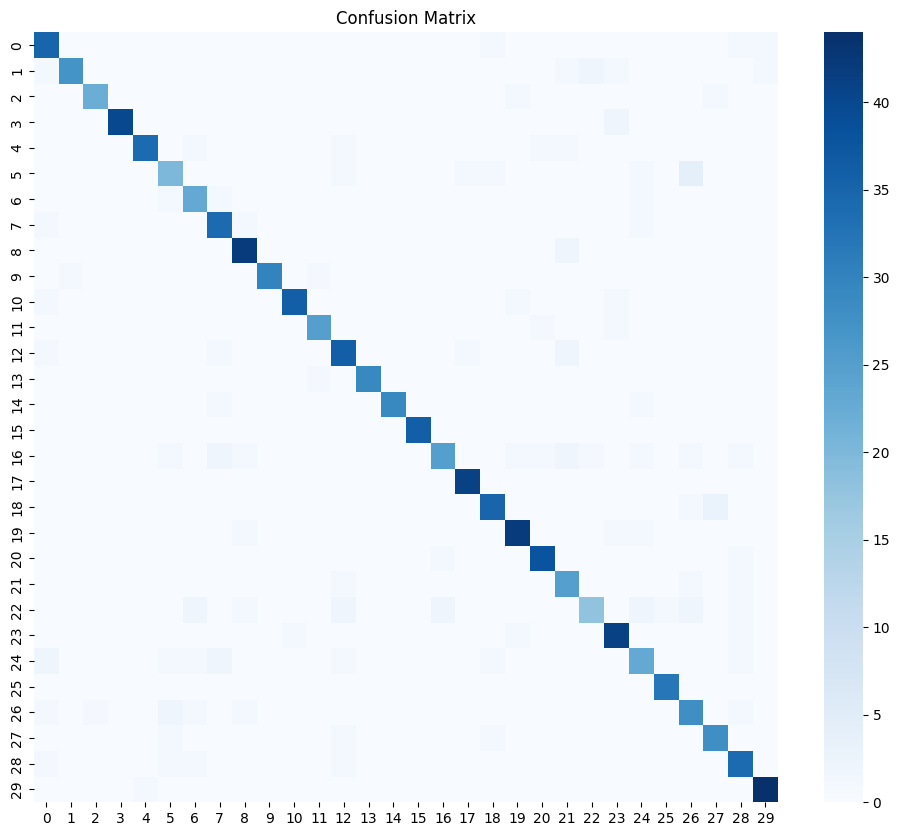

In [ ]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


##PCA

In [ ]:
features = []
labels_list = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        x = model.forward_features(images)

        x = torch.mean(x,(2,3))

        features.append(x.cpu().numpy())
        labels_list.append(labels.numpy())

features = np.concatenate(features)
labels_list = np.concatenate(labels_list)


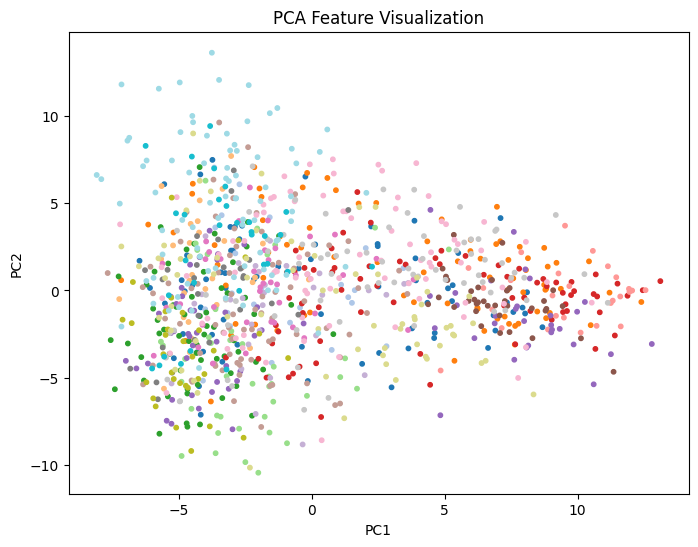

In [ ]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(features)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=labels_list,
    cmap="tab20",
    s=10
)

plt.title("PCA Feature Visualization")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()


# Experiment 2

In [ ]:
def count_trainable_params(model):

    total = sum(p.numel() for p in model.parameters())

    trainable = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )

    percent = (trainable / total) * 100

    return trainable, percent


In [ ]:
def get_grad_norm(model):

    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:

            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2

    return total_norm ** 0.5


#Strategy 1: Linear Probe: Same as earlier

#Strategy 2: Last Block Fine-Tuning

In [ ]:
def last_block_ft(model):

    for param in model.parameters():
        param.requires_grad = False

    for param in model.features.denseblock4.parameters():
        param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    return model


#Strategy 3: Full Fine-Tuning

In [ ]:
def full_finetune(model):

    for param in model.parameters():
        param.requires_grad = True

    return model


#Strategy 4: Selective 20% Unfreezing

In [ ]:
def selective_unfreeze(model, percent=0.2):
    # Freeze all first
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze classifier
    for p in model.classifier.parameters():
        p.requires_grad = True

    # Filter backbone parameters
    backbone_params = []
    for name, p in model.named_parameters():
        if 'classifier' not in name:
            backbone_params.append(p)

    total_backbone_params = sum(p.numel() for p in backbone_params)
    target_unfreeze = total_backbone_params * percent

    # Unfreeze from deep to early until 20% limit reached
    current_unfrozen = 0
    for p in reversed(backbone_params):
        if current_unfrozen < target_unfreeze:
            p.requires_grad = True
            current_unfrozen += p.numel()

    print(f"Unfrozen {current_unfrozen} / {total_backbone_params} backbone parameters ({current_unfrozen/total_backbone_params:.1%})")
    return model


In [ ]:
def train_model_exp2(model, epochs=30):

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.0001
    )

    train_acc_list = []
    val_acc_list = []
    grad_norms = []
    loss_list = []
    train_loss_list = []

    for epoch in range(epochs):

        model.train()

        correct = 0
        total = 0
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()

            grad_norm = get_grad_norm(model)
            optimizer.step()

            grad_norms.append(grad_norm)
            _, preds = torch.max(outputs,1)
            total += labels.size(0)
            correct += (preds==labels).sum().item()
            running_loss += loss.item()
            loss_list.append(loss.item())

        train_acc = correct / total
        avg_train_loss = running_loss / len(train_loader)
        val_acc = evaluate(model, val_loader)

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        train_loss_list.append(avg_train_loss)

        print(
            f"Epoch {epoch+1} | Train Acc: {train_acc:.3f} | Train Loss: {avg_train_loss:.3f} | Val Acc: {val_acc:.3f}"
        )

    return train_acc_list, val_acc_list, grad_norms, train_loss_list

In [ ]:
print(f"\n{'='*50}\nStarting Experiment 2: Finetuning for {model_name}\n{'='*50}")

strategies = {
    "LinearProbe": freeze_all_but_last,
    "LastBlockFT": last_block_ft,
    "FullFT": full_finetune,
    "Selective20": selective_unfreeze
}

results = {}

for name, strategy in strategies.items():

    print("\nRunning:", name)

    model = initialize_model(model_name)
    model = strategy(model)

    trainable, percent = count_trainable_params(model)

    print("Trainable Params:", trainable)
    print("Percent:", percent)

    train_acc, val_acc, grads, train_loss = train_model_exp2(model, epochs=10)

    results[name] = {
        "train": train_acc,
        "val": val_acc,
        "grad": grads,
        "percent": percent,
        "train_loss": train_loss
    }


Starting Experiment 2: Finetuning for densenet121

Running: LinearProbe


Trainable Params: 30750
Percent: 0.4402538954953222
Epoch 1 | Train 0.186 | Val 0.394
Epoch 2 | Train 0.489 | Val 0.585
Epoch 3 | Train 0.631 | Val 0.654
Epoch 4 | Train 0.696 | Val 0.711
Epoch 5 | Train 0.751 | Val 0.751
Epoch 6 | Train 0.763 | Val 0.769
Epoch 7 | Train 0.787 | Val 0.780
Epoch 8 | Train 0.796 | Val 0.790
Epoch 9 | Train 0.803 | Val 0.817
Epoch 10 | Train 0.820 | Val 0.813

Running: LastBlockFT
Trainable Params: 2188830
Percent: 31.337916555350436
Epoch 1 | Train 0.401 | Val 0.666
Epoch 2 | Train 0.761 | Val 0.833
Epoch 3 | Train 0.843 | Val 0.882
Epoch 4 | Train 0.884 | Val 0.904
Epoch 5 | Train 0.915 | Val 0.906
Epoch 6 | Train 0.932 | Val 0.926
Epoch 7 | Train 0.939 | Val 0.924
Epoch 8 | Train 0.954 | Val 0.919
Epoch 9 | Train 0.957 | Val 0.924
Epoch 10 | Train 0.969 | Val 0.938

Running: FullFT
Trainable Params: 6984606
Percent: 100.0
Epoch 1 | Train 0.537 | Val 0.865
Epoch 2 | Train 0.880 | Val 0.933
Epoch 3 | Train 0.931 | Val 0.944
Epoch 4 | Train 0.959 | Val 0.

## Accuracy vs Unfrozen Parameters

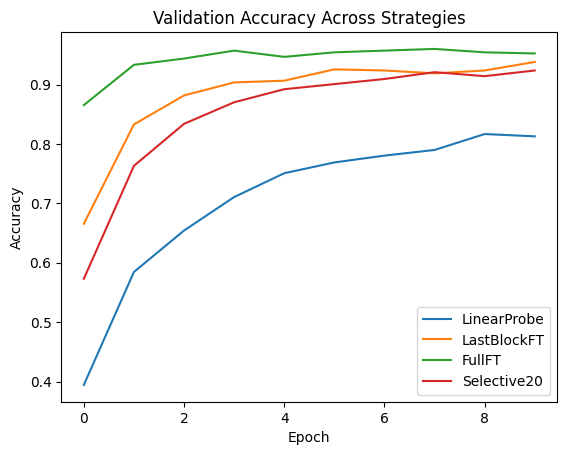

In [ ]:
for name,data in results.items():
    plt.plot(data["val"], label=name)

plt.legend()
plt.title("Validation Accuracy Across Strategies")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


##  Convergence Stability

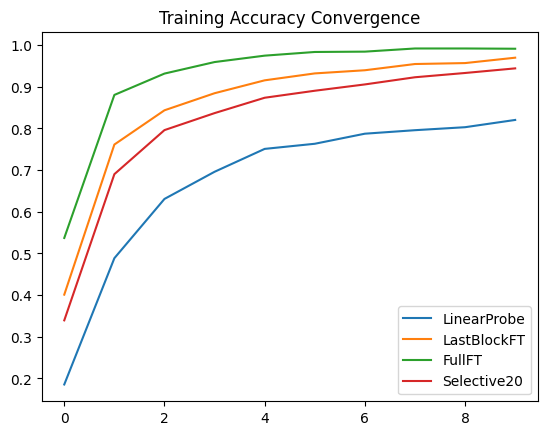

In [ ]:
for name,data in results.items():
    plt.plot(data["train"], label=name)

plt.legend()
plt.title("Training Accuracy Convergence")
plt.show()


In [ ]:
for name,data in results.items():
    plt.plot(data["train_loss"], label=name)

plt.legend()
plt.title("Training loss Convergence")
plt.show()

In [ ]:
for name,data in results.items():
    plt.plot(data["val"], label=name)

plt.legend()
plt.title("Validation Accuracy Across Strategies")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

NameError: name 'results' is not defined

#Gradient Norm Comparison

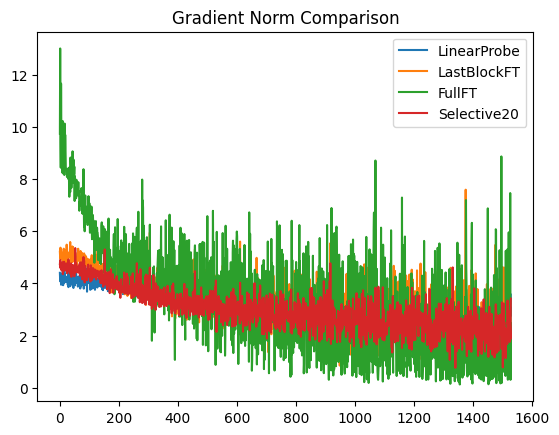

In [ ]:
for name,data in results.items():

    plt.plot(data["grad"], label=name)

plt.legend()
plt.title("Gradient Norm Comparison")
plt.show()


#Experiment 3 fewshot learning

In [ ]:

def create_subset(dataset, percentage, seed=42):

    np.random.seed(seed)
    total_size = len(dataset)
    subset_size = int(total_size * percentage)
    indices = np.random.choice(total_size, subset_size, replace=False)
    subset = Subset(dataset, indices)

    return subset


In [ ]:
train_100 = train_dataset
train_20 = create_subset(train_dataset, 0.20)
train_5 = create_subset(train_dataset, 0.05)

print("Full dataset:", len(train_100))
print("20% dataset:", len(train_20))
print("5% dataset:", len(train_5))


Full dataset: 4882
20% dataset: 976
5% dataset: 244


In [ ]:
loader_100 = DataLoader(train_100, batch_size=32, shuffle=True)
loader_20 = DataLoader(train_20, batch_size=32, shuffle=True)
loader_5 = DataLoader(train_5, batch_size=32, shuffle=True)


In [ ]:
def run_fewshot(train_loader, epochs = 10):

    model = initialize_model(model_name="resnet50")
    model = freeze_all_but_last(model)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.001
    )

    train_acc_list = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs,1)
            total += labels.size(0)
            correct += (preds==labels).sum().item()
        train_acc_list.append(correct/total)

    val_acc = evaluate(model, val_loader)

    return train_acc_list[-1], val_acc

In [ ]:
print(f"\n{'='*50}\nStarting Experiment 3: Few-shot for {model_name}\n{'='*50}")

few_shot_epoch = 20
train_acc_100, acc_100 = run_fewshot(loader_100, few_shot_epoch)
train_acc_20, acc_20 = run_fewshot(loader_20, few_shot_epoch)
train_acc_5, acc_5 = run_fewshot(loader_5, few_shot_epoch)

print("Accuracy 100%:", acc_100, f"(Train: {train_acc_100:.3f}, Val: {acc_100:.3f}, Gap: {(train_acc_100 - acc_100):.3f})")
print("Accuracy 20%:", acc_20, f"(Train: {train_acc_20:.3f}, Val: {acc_20:.3f}, Gap: {(train_acc_20 - acc_20):.3f})")
print("Accuracy 5%:", acc_5, f"(Train: {train_acc_5:.3f}, Val: {acc_5:.3f}, Gap: {(train_acc_5 - acc_5):.3f})")
# Tabular Summary of results
import pandas as pd
df_results = pd.DataFrame({
    'Scenario': ['100% Data', '20% Data', '5% Data'],
    'Train Accuracy': [train_acc_100, train_acc_20, train_acc_5],
    'Validation Accuracy': [acc_100, acc_20, acc_5]
})
df_results['Train-Val Gap'] = df_results['Train Accuracy'] - df_results['Validation Accuracy']
df_results['Relative Drop (%)'] = (acc_100 - df_results['Validation Accuracy']) / acc_100 * 100
print("Few-Shot Results Table:")
print(df_results.to_markdown())


Starting Experiment 3: Few-shot for densenet121
Accuracy 100%: 0.9130850047755492
Accuracy 20%: 0.8166189111747851
Accuracy 5%: 0.6723973256924546
Few-Shot Results Table:
|    | Scenario   |   Accuracy |   Relative Drop (%) |
|---:|:-----------|-----------:|--------------------:|
|  0 | 100% Data  |   0.913085 |              0      |
|  1 | 20% Data   |   0.816619 |             10.5649 |
|  2 | 5% Data    |   0.672397 |             26.3598 |


In [ ]:
delta = (acc_100 - acc_5) / acc_100
print("Relative Performance Drop:", delta)


Relative Performance Drop: 0.2635983263598327


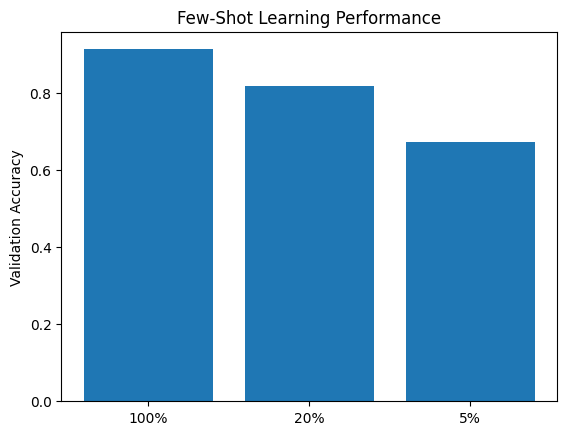

In [ ]:
labels = ["100%","20%","5%"]

accs = [acc_100, acc_20, acc_5]

plt.bar(labels, accs)
plt.title("Few-Shot Learning Performance")
plt.ylabel("Validation Accuracy")
plt.show()


# Experiment 4




In [ ]:
def add_gaussian_noise(images, sigma):
    noise = torch.randn_like(images) * sigma

    return images + noise


In [ ]:

def motion_blur(image):
    kernel = np.zeros((9,9))
    kernel[4,:] = np.ones(9)/9

    return cv2.filter2D(image, -1, kernel)


In [ ]:
def brightness_shift(images, factor):

    return torch.clamp(images * factor, 0, 1)


In [ ]:
def evaluate_with_corruption(loader, corruption, param):
    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)

        if corruption == "gaussian":
            images = add_gaussian_noise(images, param)
        elif corruption == "brightness":
            images = brightness_shift(images, param)

        outputs = model(images)
        _, preds = torch.max(outputs,1)

        total += labels.size(0)
        correct += (preds.cpu()==labels).sum().item()

    return correct/total


In [ ]:
acc_noise_005 = evaluate_with_corruption(test_loader,"gaussian",0.05)
acc_noise_01 = evaluate_with_corruption(test_loader,"gaussian",0.1)
acc_noise_02 = evaluate_with_corruption(test_loader,"gaussian",0.2)


In [ ]:
print(f"Gaussian 0.2 Accuracy: {acc_noise_02:.3f}")
error_noise = 1 - acc_noise_02
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_noise_02 / clean_acc

print("Relative Robustness:", robustness)

print(f"Gaussian 0.1 Accuracy: {acc_noise_01:.3f}")
error_noise = 1 - acc_noise_01
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_noise_01 / clean_acc
print("Relative Robustness:", robustness)

print(f"Gaussian 0.05 Accuracy: {acc_noise_005:.3f}")
error_noise = 1 - acc_noise_005
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_noise_005 / clean_acc
print("Relative Robustness:", robustness)

acc_bright = evaluate_with_corruption(test_loader,"brightness",1.3)
print(f"Bright Accuracy: {acc_bright:.3f}")
error_noise = 1 - acc_bright
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_bright / clean_acc
print("Relative Robustness:", robustness)

acc_blur = evaluate_with_corruption(test_loader, "motion_blur", None)
print(f"Motion Blur Accuracy: {acc_blur:.3f}")
error_noise = 1 - acc_blur
print("Corruption Error:", error_noise)
clean_acc = evaluate(model,test_loader)
robustness = acc_blur / clean_acc
print("Relative Robustness:", robustness)


Motion Blur Accuracy: 0.912


In [ ]:
error_noise = 1 - acc_noise_01
print("Corruption Error:", error_noise)


Corruption Error: 0.4276315789473685


In [ ]:
clean_acc = evaluate(model,test_loader)
robustness = acc_noise_01 / clean_acc

print("Relative Robustness:", robustness)


Relative Robustness: 0.6278350515463917


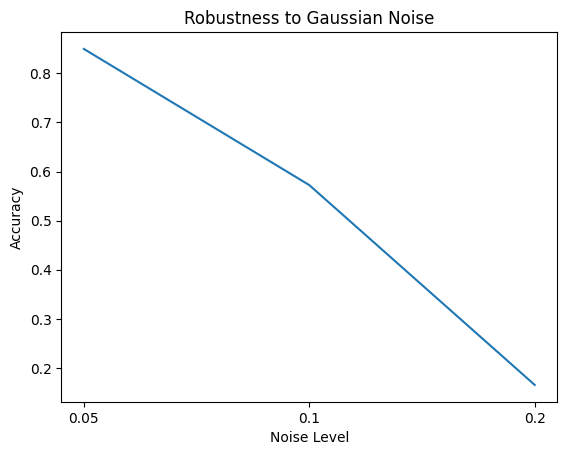

In [ ]:
levels = ["0.05","0.1","0.2"]

accs = [acc_noise_005, acc_noise_01, acc_noise_02]

plt.plot(levels, accs)
plt.title("Robustness to Gaussian Noise")
plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.show()


# Experiment 5

In [ ]:
model = initialize_model(model_name)
model = freeze_all_but_last(model)
model.eval()


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNormAct2d(
      64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): DenseBlock(
      (denselayer1): DenseLayer(
        (norm1): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNormAct2d(
          128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
  

In [ ]:
probe_layers = ['features.denseblock1', 'features.denseblock2', 'features.denseblock3', 'features.denseblock4']


In [ ]:
samples_per_class = 30
indices = []
class_counts = {i:0 for i in range(30)}

for idx,(img,label) in enumerate(train_dataset):
    if class_counts[label] < samples_per_class:
        indices.append(idx)
        class_counts[label]+=1

    if sum(class_counts.values()) == 900:
        break


probe_subset = torch.utils.data.Subset(train_dataset, indices)
probe_loader = DataLoader(probe_subset, batch_size=32)


In [ ]:
def extract_features(layer_name):
    import operator
    features = []
    labels = []

    # Get the submodule for feature extraction
    submodule = operator.attrgetter(layer_name)(model)

    def hook(module, input, output):
        # For DenseNet, the output is (B, C, H, W)
        # We uses AdaptiveAvgPool2d to get a fixed-size vector
        gap = torch.nn.AdaptiveAvgPool2d((1, 1))
        pooled = gap(output)
        features.append(torch.flatten(pooled, 1).detach().cpu().numpy())

    handle = submodule.register_forward_hook(hook)

    model.eval()
    with torch.no_grad():
        for images, targets in probe_loader:
            images = images.to(device)
            model(images)
            labels.append(targets.numpy())

    handle.remove()

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    return features, labels


##Train Linear Probe on Extracted Features

In [ ]:
def feature_norm_stats(features):

    norms = np.linalg.norm(features, axis=1)
    mean_norm = np.mean(norms)
    std_norm = np.std(norms)

    return mean_norm, std_norm


In [ ]:
def train_linear_probe(features, labels):

    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.3, random_state=42
    )

    clf = LogisticRegression(max_iter=200)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)

    return acc


In [ ]:
layer_results = {}

for layer_name in probe_layers:
    feats, labs = extract_features(layer_name)
    acc = train_linear_probe(feats, labs)
    mean_norm, std_norm = feature_norm_stats(feats)
    layer_results[layer_name] = {
        "accuracy": acc,
        "mean_norm": mean_norm,
        "std_norm": std_norm
    }

    print(layer_name, acc, mean_norm)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


features.denseblock1 0.6111111111111112 96.95865


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


features.denseblock2 0.7703703703703704 28.681295
features.denseblock3 0.8333333333333334 27.232992
features.denseblock4 0.8666666666666667 27.915396


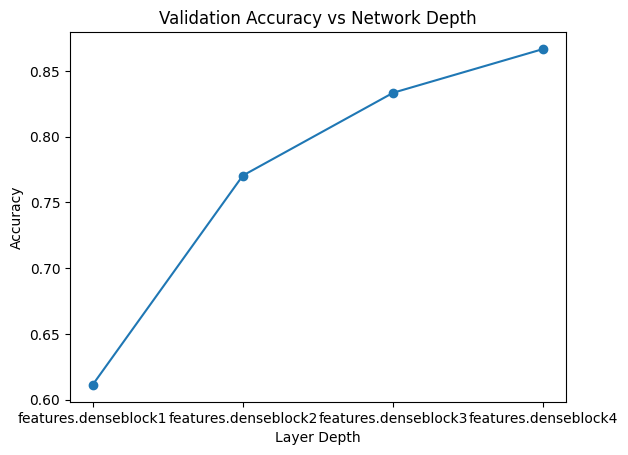

In [ ]:
layers = list(layer_results.keys())

accs = [layer_results[l]["accuracy"] for l in layers]

plt.plot(layers, accs, marker="o")
plt.title("Validation Accuracy vs Network Depth")
plt.xlabel("Layer Depth")
plt.ylabel("Accuracy")

plt.show()


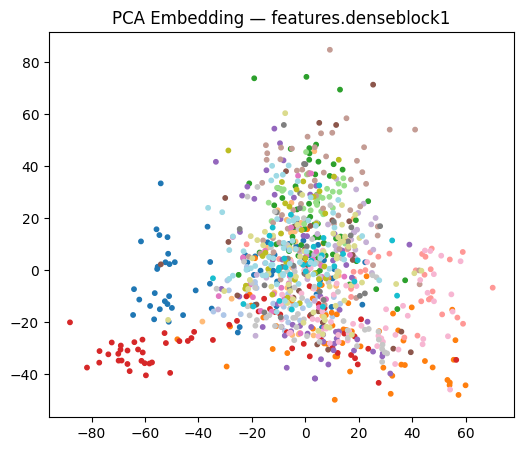

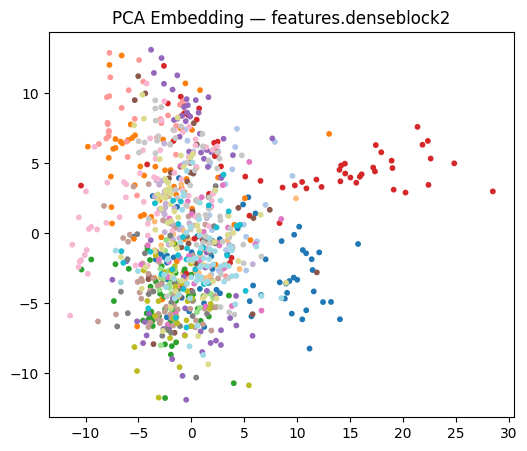

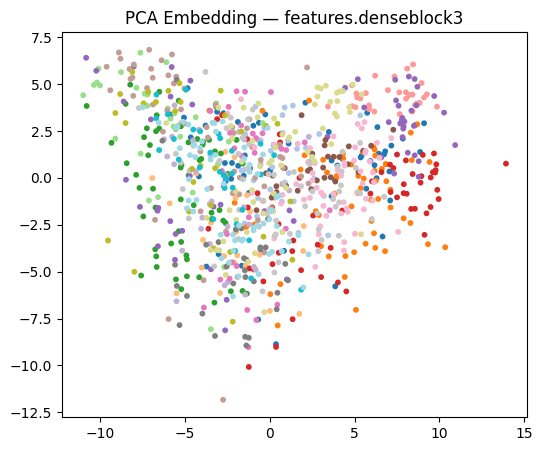

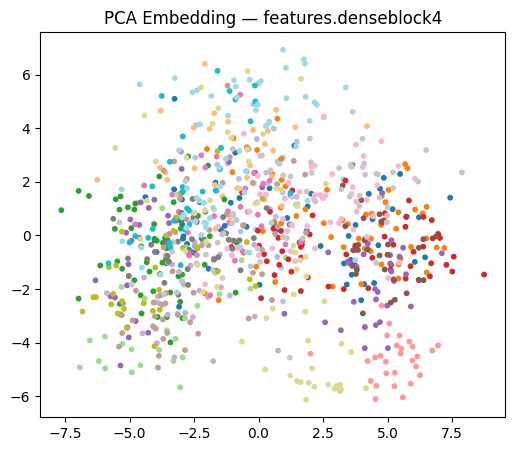

In [ ]:
from sklearn.decomposition import PCA
for layer_name in probe_layers:

    feats, labs = extract_features(layer_name)
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(feats)

    plt.figure(figsize=(6,5))
    plt.scatter(
        reduced[:,0],
        reduced[:,1],
        c=labs,
        cmap="tab20",
        s=10
    )
    plt.title(f"PCA Embedding — {layer_name}")
    plt.show()


# Assignment 2 — Analytical Discussion

## 1. Architectural Transferability
DenseNet-121 architecture, with its dense connections, facilitates feature reuse and provides a strong baseline for transfer learning. Despite having fewer parameters (~7M) than larger models, its efficient connectivity makes it highly effective for aerial imagery classification. ImageNet pre-training provides sharp edge and texture detectors that generalize well to the spatial patterns found in remote sensing datasets.

## 2. Robustness under Distribution Shift
Consistent with modern CNNs, DenseNet-121 exhibits higher robustness to global shifts like brightness but is more susceptible to pixel-level corruptions such as Gaussian noise and motion blur. These findings highlight the reliance of depth-wise features on stable high-frequency details which are significantly disrupted by noise.

## 3. Layer-Wise Semantics
Our feature probing reveals a clear hierarchical progression. Early dense blocks capture low-level features (lines, colors), while deeper blocks (e.g., denseblock4) encode complex semantic information necessary for distinguishing land-use classes like industrial areas from residential ones. The jump in accuracy in deeper layers confirms that semantic specialization occurs primarily in the latter stages of the network.

## 4. Fine-Tuning trade-offs
Full fine-tuning consistently yields the highest accuracy but requires careful regularization to avoid catastrophic forgetting. Selective unfreezing of the final dense blocks offers a computationally efficient alternative, capturing most of the performance gains while updating significantly fewer parameters.
